In [5]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
plt.rcParams['font.family']='Times New Roman,Microsoft YaHei'# 设置字体族，中文为微软雅黑，英文为Times New Roman
plt.rcParams['mathtext.fontset'] = 'stix' # 设置数%matplotlib qt学公式字体为stix
plt.style.use('seaborn-v0_8-paper')
# 设置全局参数
plt.rcParams['figure.facecolor'] = 'white'  # 设置图形的背景为透明
plt.rcParams['axes.facecolor'] = 'white'    # 设置轴域的背景为透明
plt.rcParams['savefig.facecolor'] = 'white' # 保存图像时背景透明
import matplotlib
# matplotlib.use('TkAgg')
%matplotlib inline

In [6]:
df=pd.read_pickle("music_var_chordkey.pkl")

In [7]:
# df=df.sample(frac=0.01)

In [8]:
# 去除重复列
df = df.loc[:, ~df.columns.duplicated()]

# 定义高度替换规则
def replace_level(row):
    if row['place'] == 'ZS':
        return '3 m' if row['level'] == 1 else f"{row['level']}m"
    elif row['place'] == 'JH':
        return {1: '1.5 m', 2: '4 m', 3: '8 m', 4: '14 m'}.get(row['level'], f"{row['level']}m")
    elif row['place'] == 'CM':
        return {1: '1.5 m', 2: '10 m', 3: '16 m', 4: '22 m'}.get(row['level'], f"{row['level']}m")
    return f"{row['level']}m"

# 替换 level 列的值
df['level'] = df.apply(replace_level, axis=1)

# 转换 `key` 列
def parse_key(key_str):
    # 去掉大括号和空格，按逗号分割字符串
    key_str = key_str.strip('{}').replace(' ', '').split(',')
    # 将所有值转换为浮点数
    return np.array([float(k) for k in key_str])

# 应用转换函数
df['Key'] = df['Key'].apply(parse_key)


In [9]:
# 设置24个调性名称
key_names = ['A major', 'Bb major', 'B major', 'C major', 'Db major',
              'D major', 'Eb major', 'E major', 'F major', 'F# major',
              'G major', 'Ab major', 'A minor', 'Bb minor', 'B minor',
              'C minor', 'C# minor', 'D minor', 'D# minor', 'E minor',
              'F minor', 'F# minor', 'G minor', 'G# minor']

# 从每行的 Key 数组中选择置信度最大的 Key
df['Dominant_Key'] = df['Key'].apply(lambda x: key_names[np.argmax(x)])

In [10]:
# 确保Date列是datetime类型，并向下舍入到最近的30分钟
df['Date'] = pd.to_datetime(df['Date'])
df['Time_Block'] = df['Date'].dt.floor('30min').dt.strftime('%H:%M')  # 使用 '30min' 替代 '30T'

In [11]:
# 计数每个Dominant_Key在每个时间段的出现次数
df_grouped = df.copy().groupby(['Time_Block', 'Dominant_Key'], observed=False).size().unstack(fill_value=0)
# 根据索引排序
df_grouped = df_grouped.sort_index()
# 转换数据以适应图形显示
df_pivot = df_grouped.T  # 转置以使Dominant_Key为行，时间段为列

#计算每个 Dominant_Key 的总出现次数
df_pivot['Total'] = df_pivot.sum(axis=1)
# 根据总量进行排序
df_pivot = df_pivot.sort_values(by='Total', ascending=False)
# 删除 'Total' 列，因为它不需要在绘图中展示
df_pivot = df_pivot.drop(columns='Total')

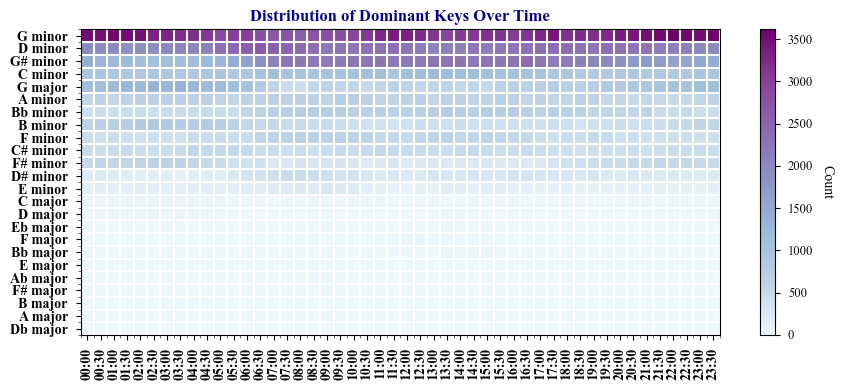

In [12]:
from palettable.colorbrewer.sequential import BuPu_7

# 绘图设置
fig = plt.figure(figsize=(9, 4))  # 图片大小
ax = fig.add_subplot(111)
cax = ax.imshow(df_pivot, aspect='auto', interpolation='none', cmap=BuPu_7.mpl_colormap)  

# 设置主要刻度
ax.set_xticks(np.arange(len(df_grouped.index)))
ax.set_yticks(np.arange(len(df_pivot.index)))

# 设置刻度标签
ax.set_xticklabels(df_grouped.index, rotation=90, fontsize=10, fontweight='bold')  # 加粗字体，增大字号
ax.set_yticklabels(df_pivot.index, fontsize=10, fontweight='bold')  # 加粗字体，增大字号

# 设置次要刻度以显示网格线
ax.set_xticks(np.arange(-0.5, len(df_grouped.index), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(df_pivot.index), 1), minor=True)

# 绘制网格线
ax.grid(which='minor', color='w', linestyle='-', linewidth=1.5)  # 增加网格线宽度
ax.grid(which='major', color='w', linestyle='-', linewidth=0)

# 设置标题
ax.set_title('Distribution of Dominant Keys Over Time', fontsize=12, fontweight='bold', color='darkblue')

# 添加颜色条，调整颜色条的属性
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label('Count', rotation=270, fontsize=10, labelpad=15)  # 设置颜色条标签和位置
cbar.ax.tick_params(labelsize=9)  # 设置颜色条刻度的字体大小

fig.tight_layout()  # 紧凑布局
# plt.savefig('调性24h变化.svg', bbox_inches='tight', pad_inches=0.1,dpi=500)
# plt.savefig('调性24h变化.png', bbox_inches='tight', pad_inches=0.1,dpi=500)
plt.show()

In [13]:
df['Month'] = df['Date'].dt.month
month_order = [12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
df = df.sort_values('Month')

In [14]:
month_labels = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 
                7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
df['Monthtext'] = df['Month'].map(month_labels)
month_order = ['Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov']
df['Monthtext'] = pd.Categorical(df['Monthtext'], categories=month_order, ordered=True)
df = df.sort_values('Monthtext')

In [15]:
# 计数每个Dominant_Key在每个时间段的出现次数
df_grouped = df.copy().groupby(['Monthtext', 'Dominant_Key'], observed=False).size().unstack(fill_value=0)
# 转换数据以适应图形显示
df_pivot = df_grouped.T  # 转置以使Dominant_Key为行，时间段为列

#计算每个 Dominant_Key 的总出现次数
df_pivot['Total'] = df_pivot.sum(axis=1)
# 根据总量进行排序
df_pivot = df_pivot.sort_values(by='Total', ascending=False)
# 删除 'Total' 列，因为它不需要在绘图中展示
df_pivot = df_pivot.drop(columns='Total')

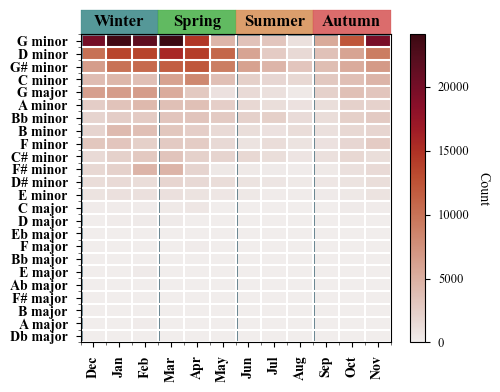

In [16]:
from palettable.cmocean.sequential import Amp_14

# 绘图设置
fig = plt.figure(figsize=(5, 4))  # 图片大小
ax = fig.add_subplot(111)
cax = ax.imshow(df_pivot, aspect='auto', interpolation='none', cmap=Amp_14.mpl_colormap)

# 设置主要刻度
ax.set_xticks(np.arange(len(df_grouped.index)))
ax.set_yticks(np.arange(len(df_pivot.index)))


# 设置刻度标签
ax.set_xticklabels(df_grouped.index, rotation=90, fontsize=10, fontweight='bold')  # 加粗字体，增大字号
ax.set_yticklabels(df_pivot.index, fontsize=10, fontweight='bold')  # 加粗字体，增大字号

# 设置次要刻度以显示网格线
ax.set_xticks(np.arange(-0.5, len(df_grouped.index), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(df_pivot.index), 1), minor=True)

# 绘制网格线
ax.grid(which='minor', color='w', linestyle='-', linewidth=1.5)  # 增加网格线宽度
ax.grid(which='major', color='w', linestyle='-', linewidth=0)

# 设置标题
ax.set_title('', fontsize=12, fontweight='bold', color='darkblue',y=1.07)

# 添加颜色条，调整颜色条的属性
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label('Count', rotation=270, fontsize=10, labelpad=15)  # 设置颜色条标签和位置
cbar.ax.tick_params(labelsize=9)  # 设置颜色条刻度的字体大小


seasons = {
    'Winter': ['Dec', 'Jan', 'Feb'],
    'Spring': ['Mar', 'Apr', 'May'],
    'Summer': ['Jun', 'Jul', 'Aug'],
    'Autumn': ['Sep', 'Oct', 'Nov']
}
for season, months in seasons.items():
    start_idx = df_grouped.index.get_loc(months[0])
    end_idx = df_grouped.index.get_loc(months[-1])
    
    # 绘制黑色矩形框
    ax.add_patch(plt.Rectangle((start_idx - 0.5, -0.5), len(months), len(df_pivot.index), 
                               fill=False, edgecolor='#66828E', facecolor='#66828E', lw=2))
    
# 定义季节及其对应的月份范围和背景颜色
seasons = [('Winter', 0.5, 3.5, '#2B7E7E'),   # Start, End, Color
           ('Spring', 3.5, 6.5, '#39A939'),
           ('Summer', 6.5, 9.5, '#D38647'),
           ('Autumn', 9.5, 12.5, '#D34747')] 


import matplotlib.patches as patches
# 在 x 轴上方添加表示季节的矩形背景
y_pos = 1  # 在图表顶部绘制
rect_height = 0.08  # 矩形高度

for season, start, end, color in seasons:
    ax.add_patch(
        patches.Rectangle(
            (start - 1, y_pos),  # 矩形的 (x, y) 位置
            end - start,     # 矩形的宽度
            rect_height,     # 矩形的高度
            color=color,
            alpha=0.8,
            transform=ax.get_xaxis_transform(),  # 位置相对于 x 轴
            clip_on=False    # 绘制在图表区域之外
        )
    )

# 在矩形背景上方添加季节名称
for season, start, end, color in seasons:
    ax.text((start - 2 + end) / 2, y_pos + rect_height / 2, season,
            ha='center', va='center', fontsize=12, fontweight='bold', color='black',
            transform=ax.get_xaxis_transform(), clip_on=False)




# fig.tight_layout()  # 紧凑布局
plt.savefig('调性月份变化.svg', bbox_inches='tight', pad_inches=0.1,dpi=500)
plt.savefig('调性月份变化.png', bbox_inches='tight', pad_inches=0.1,dpi=500)
plt.show()

In [ ]:
# import re
# def extract_chords(chords_str):
#     # 使用正则表达式提取括号中的第三个元素
#     pattern = r'\((?:[^,]+,){2}([^,)]+)\)'
#     return re.findall(pattern, chords_str)
# 
# # 应用函数并创建新的 DataFrame
# df_chordkey = df.apply(lambda row: pd.Series({
#     'sample': row['Time_Block'],
#     'track': row['Dominant_Key'],
#     'event': extract_chords(row['Chords']),
#     'place':row["place"],
#     'level':row["level"],
#     'Date':row["Date"],
# }), axis=1).explode('event').reset_index(drop=True)
# # 删除 event 列为 'N' 的行
# df_chordkey = df_chordkey[df_chordkey['event'] != 'N']

In [ ]:
# df_chordkey.to_pickle("df_chordkey,pkl")

In [ ]:
df_chordkey=pd.read_pickle("df_chordkey,pkl")

In [ ]:
df_chordkey

In [17]:
from oncoprinter import OncoPrint
import marsilea as ma
import marsilea.plotter as mp

In [18]:
def removechordkey_time(df_chordkey,chordbound=0.05,keybound=0.05):
    # 计算每个和弦的出现次数
    event_counts = df_chordkey['event'].value_counts()
    # 计算每个track的出现次数
    track_counts = df_chordkey['track'].value_counts()
    # 计算总数的1%
    event_threshold = len(df_chordkey) * chordbound
    track_threshold = len(df_chordkey) * keybound
    # 过滤掉出现次数低于1%的和弦和track
    filtered_events = event_counts[event_counts > event_threshold].index.tolist()
    filtered_tracks = track_counts[track_counts > track_threshold].index.tolist()
    # 创建一个过滤后的DataFrame
    filtered_df = df_chordkey[df_chordkey['event'].isin(filtered_events) & df_chordkey['track'].isin(filtered_tracks)]
    return filtered_df

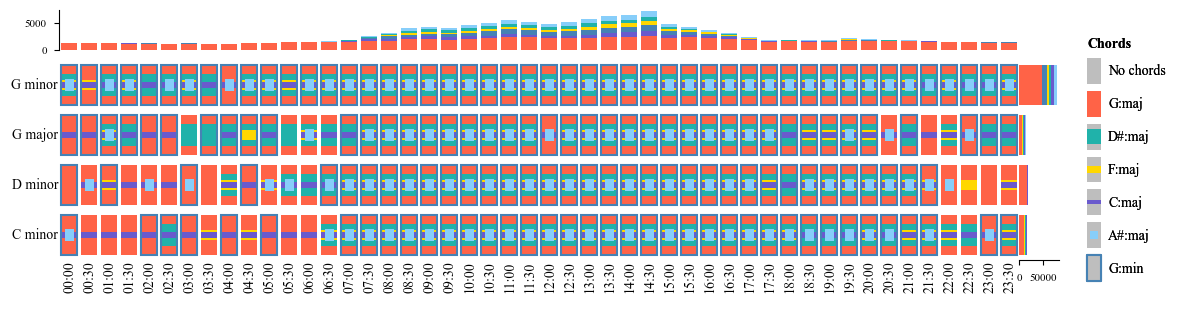

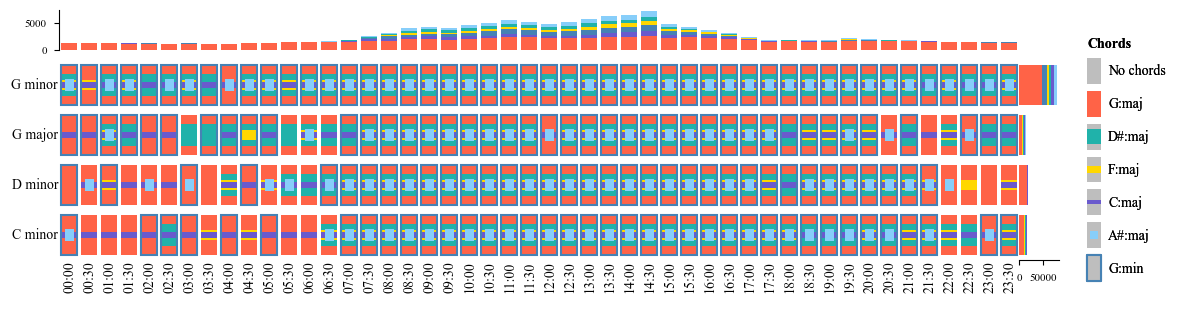

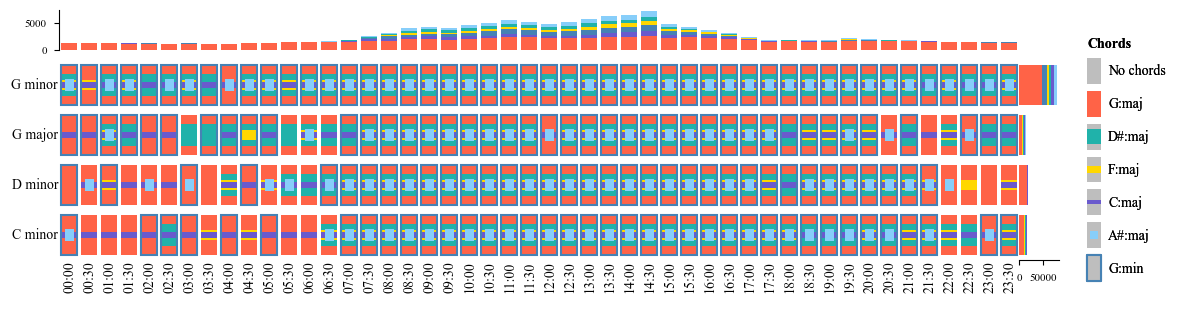

In [19]:
filtered_df=removechordkey_time(df_chordkey[df_chordkey.place=='ZS'])
track_counts = filtered_df['track'].value_counts()
tracks_order = track_counts.index.tolist()
op = OncoPrint(filtered_df.sort_values(by='sample').iloc[:,0:3] , name="main",add_tracks_counts="right", add_mut_perc=None, tracks_order=tracks_order,add_tracks_counts_size=0.4,add_mut_counts_size=0.4)
op.render()
op.save("ZSchordskettime op图.svg", transparent=True)
op.save("ZSchordskettime op图.png", transparent=True)

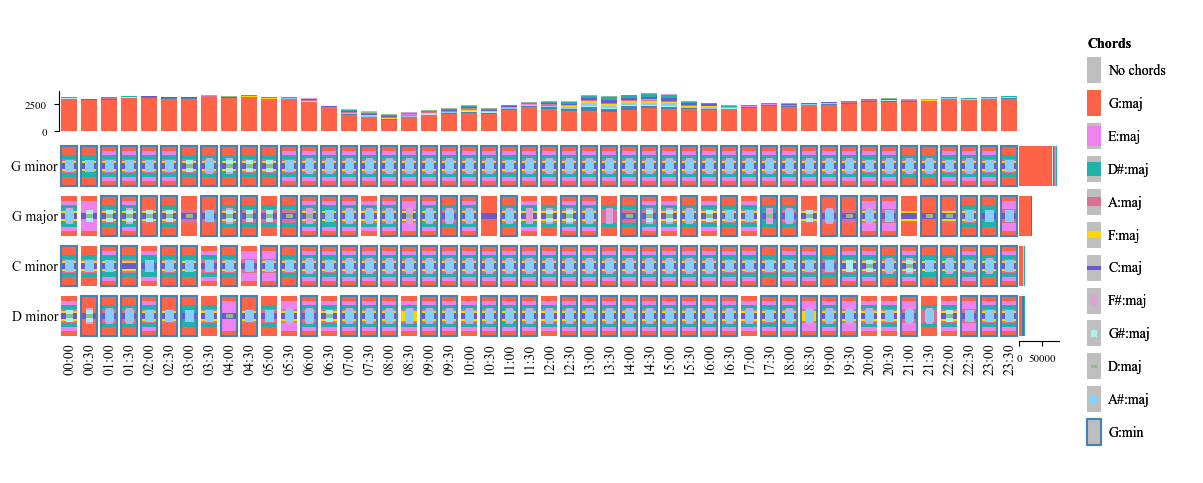

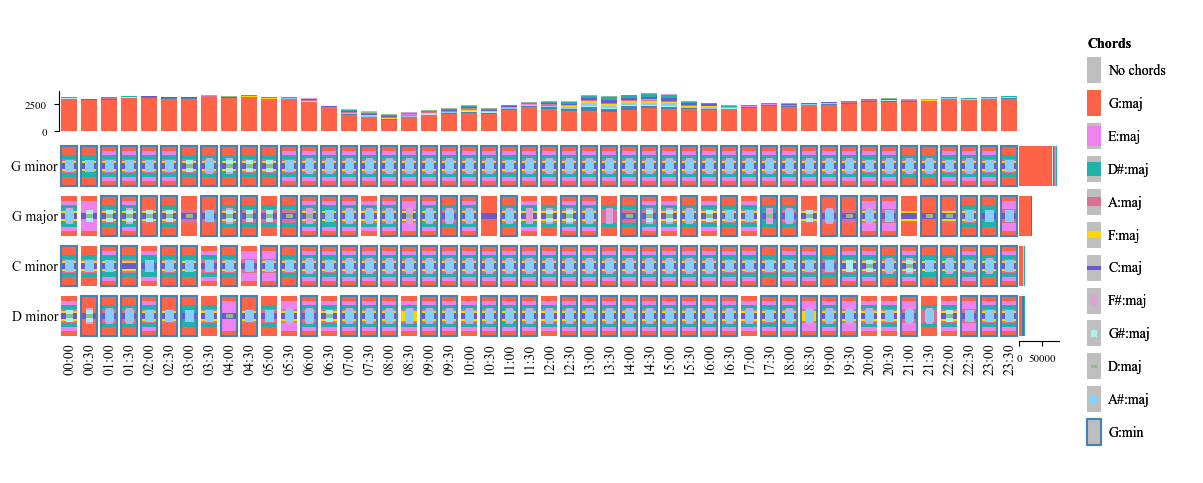

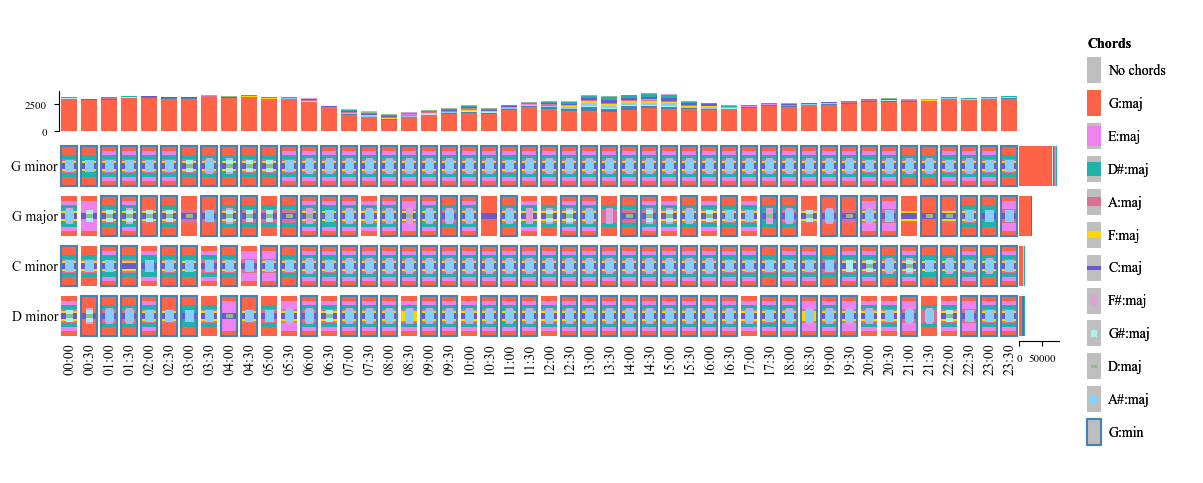

In [20]:
filtered_df=removechordkey_time(df_chordkey[df_chordkey.place=='CM'],chordbound=0.01)
track_counts = filtered_df['track'].value_counts()
tracks_order = track_counts.index.tolist()
op = OncoPrint(filtered_df.sort_values(by='sample').iloc[:,0:3] , name="main",add_tracks_counts="right", add_mut_perc=None, tracks_order=tracks_order,add_tracks_counts_size=0.4,add_mut_counts_size=0.4)
op.render()
op.save("CMchordskettime op图.svg", transparent=True)
op.save("CMchordskettime op图.png", transparent=True)

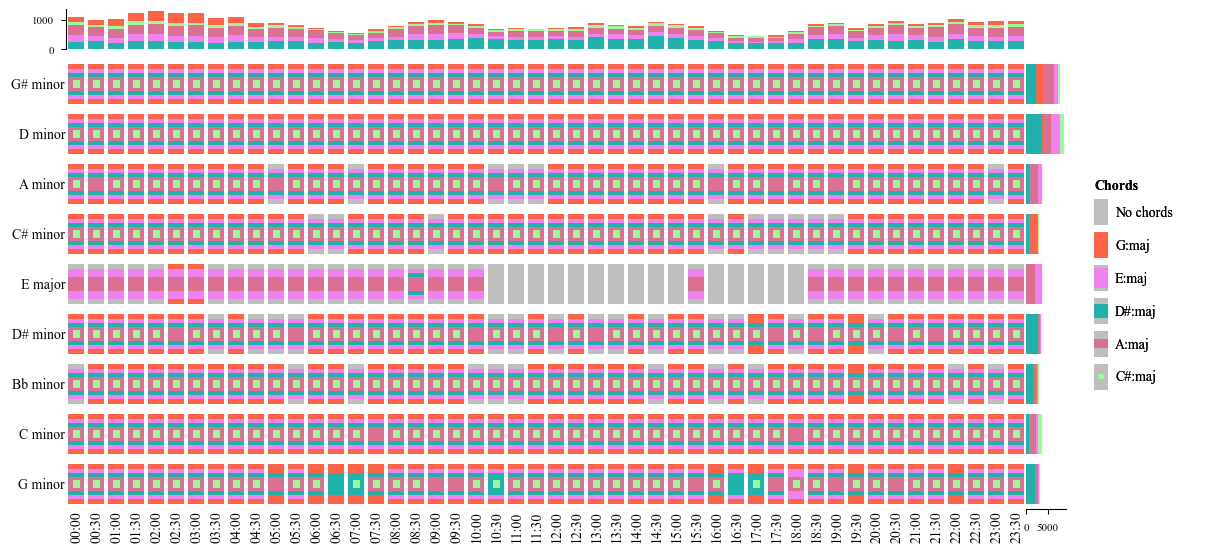

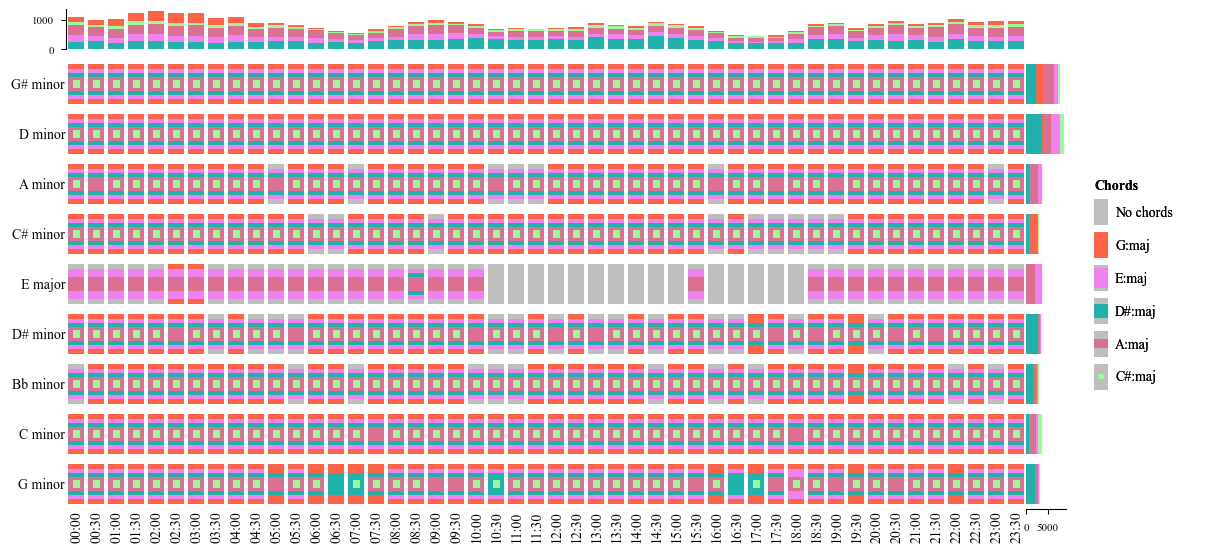

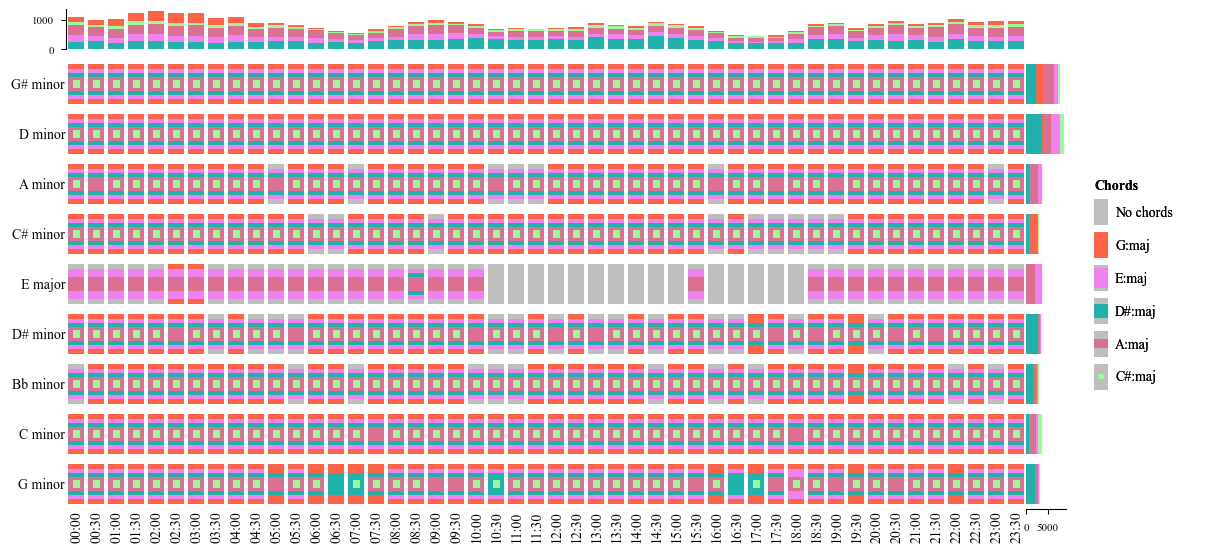

In [21]:
filtered_df=removechordkey_time(df_chordkey[df_chordkey.place=='JH'])
track_counts = filtered_df['track'].value_counts()
tracks_order = track_counts.index.tolist()
op = OncoPrint(filtered_df.sort_values(by='sample').iloc[:,0:3] , name="main",add_tracks_counts="right", add_mut_perc=None, tracks_order=tracks_order,add_tracks_counts_size=0.4,add_mut_counts_size=0.4)
op.render()
op.save("JHchordskettime op图.svg", transparent=True)
op.save("JHchordskettime op图.png", transparent=True)

In [22]:
def removechordkey_month(df_chordkey,chordbound=0.05,keybound=0.05):
    df_chordkey['Month'] = df_chordkey['Date'].dt.month
    month_order = [12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
    df_chordkey['Month'] = pd.Categorical(df_chordkey['Month'], categories=month_order, ordered=True)
    df_chordkey = df_chordkey.sort_values('Month')
    month_labels = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    df_chordkey['Monthtext'] = df_chordkey['Month'].map(month_labels)
    month_order = ['Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov']
    df_chordkey['Monthtext'] = pd.Categorical(df_chordkey['Monthtext'], categories=month_order, ordered=True)
    df_chordkey = df_chordkey.sort_values('Monthtext')
    df_chordkey['sample']=df_chordkey["Monthtext"]
    
    # 计算每个和弦的出现次数
    event_counts = df_chordkey['event'].value_counts()
    # 计算每个track的出现次数
    track_counts = df_chordkey['track'].value_counts()
    # 计算总数的1%
    event_threshold = len(df_chordkey) * chordbound
    track_threshold = len(df_chordkey) * keybound
    # 过滤掉出现次数低于1%的和弦和track
    filtered_events = event_counts[event_counts > event_threshold].index.tolist()
    filtered_tracks = track_counts[track_counts > track_threshold].index.tolist()
    # 创建一个过滤后的DataFrame
    filtered_df = df_chordkey[df_chordkey['event'].isin(filtered_events) & df_chordkey['track'].isin(filtered_tracks)]
    return filtered_df

C:\Users\aa271\AppData\Local\Temp\ipykernel_26592\2859740128.py:22: DeprecationWarning: `vsplit` will be deprecated in v0.5.0, use `cut_cols` or `group_cols` instead
  op.vsplit(labels=cell_cat, order=["Winter", "Spring", "Summer", "Autumn"])


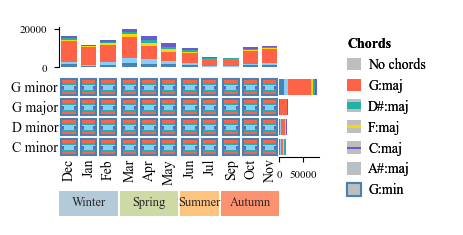

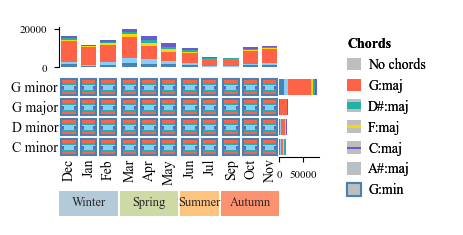

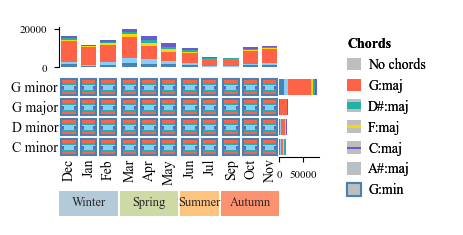

In [23]:
filtered_df=removechordkey_month(df_chordkey[df_chordkey.place=='ZS'].copy())
track_counts = filtered_df['track'].value_counts()
tracks_order = track_counts.index.tolist()
op = OncoPrint(filtered_df.sort_values(by='sample').iloc[:,0:3] , name="main",add_tracks_counts="right", add_mut_perc=None, tracks_order=tracks_order,add_tracks_counts_size=0.4,add_mut_counts_size=0.4,aspect=1)

cell_cat = [
    "Winter",  # December
    "Winter",  # January
    "Winter",  # February
    "Spring",  # March
    "Spring",  # April
    "Spring",  # May
    "Summer",  # June
    "Summer",  # July
    # "Summer",  # August
    "Autumn",  # September
    "Autumn",  # October
    "Autumn",  # November
]

props = {'fontsize': 9}  # 设置字体大小为12
op.vsplit(labels=cell_cat, order=["Winter", "Spring", "Summer", "Autumn"])
op.add_bottom(mp.Chunk(
    ["Winter", "Spring", "Summer", "Autumn"],  # 季节名称
    ["#B3CAD8", "#CDDAA5", "#FEC37D", "#FD9270"],props=props), pad=0.05)
op.render()
op.save("ZSchordskemonth op图.svg", transparent=True)
op.save("ZSchordskemonth op图.png", transparent=True)

C:\Users\aa271\AppData\Local\Temp\ipykernel_26592\325119208.py:22: DeprecationWarning: `vsplit` will be deprecated in v0.5.0, use `cut_cols` or `group_cols` instead
  op.vsplit(labels=cell_cat, order=["Winter", "Spring", "Summer", "Autumn"])


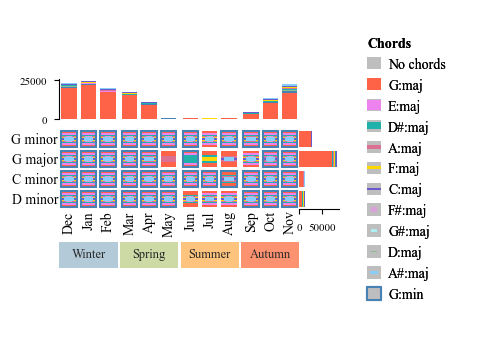

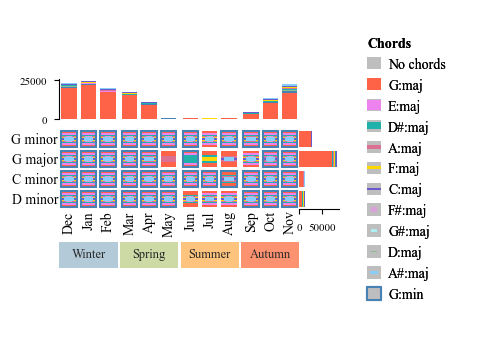

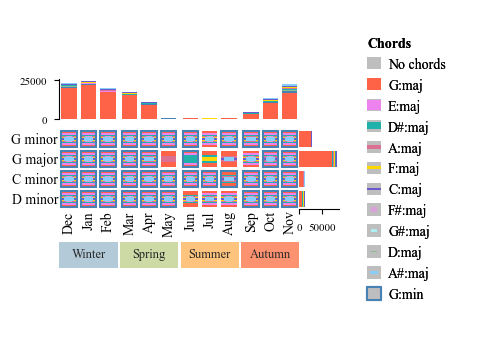

In [24]:
filtered_df=removechordkey_month(df_chordkey[df_chordkey.place=='CM'].copy(),chordbound=0.01)
track_counts = filtered_df['track'].value_counts()
tracks_order = track_counts.index.tolist()
op = OncoPrint(filtered_df.sort_values(by='sample').iloc[:,0:3] , name="main",add_tracks_counts="right", add_mut_perc=None, tracks_order=tracks_order,add_tracks_counts_size=0.4,add_mut_counts_size=0.4,aspect=1)

cell_cat = [
    "Winter",  # December
    "Winter",  # January
    "Winter",  # February
    "Spring",  # March
    "Spring",  # April
    "Spring",  # May
    "Summer",  # June
    "Summer",  # July
    "Summer",  # August
    "Autumn",  # September
    "Autumn",  # October
    "Autumn",  # November
]

props = {'fontsize': 9}  # 设置字体大小为12
op.vsplit(labels=cell_cat, order=["Winter", "Spring", "Summer", "Autumn"])
op.add_bottom(mp.Chunk(
    ["Winter", "Spring", "Summer", "Autumn"],  # 季节名称
    ["#B3CAD8", "#CDDAA5", "#FEC37D", "#FD9270"],props=props), pad=0.05)
op.render()
op.save("CMchordskemonth op图.svg", transparent=True)
op.save("CMchordskemonth op图.png", transparent=True)

C:\Users\aa271\AppData\Local\Temp\ipykernel_26592\695244595.py:22: DeprecationWarning: `vsplit` will be deprecated in v0.5.0, use `cut_cols` or `group_cols` instead
  op.vsplit(labels=cell_cat, order=["Winter", "Spring", "Summer", "Autumn"])


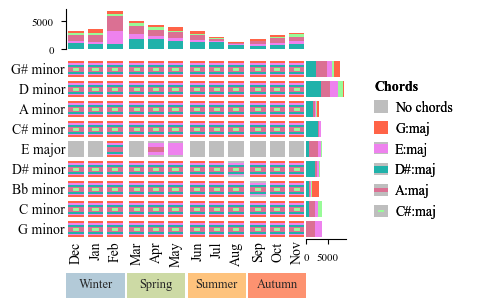

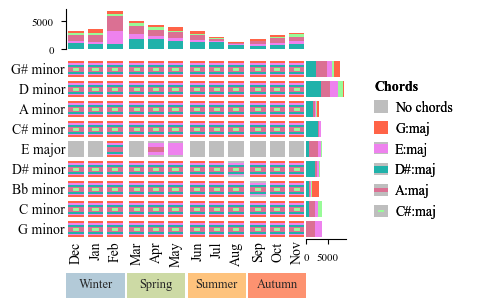

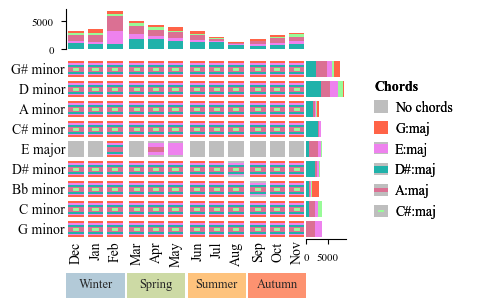

In [25]:
filtered_df=removechordkey_month(df_chordkey[df_chordkey.place=='JH'].copy())
track_counts = filtered_df['track'].value_counts()
tracks_order = track_counts.index.tolist()
op = OncoPrint(filtered_df.sort_values(by='sample').iloc[:,0:3] , name="main",add_tracks_counts="right", add_mut_perc=None, tracks_order=tracks_order,add_tracks_counts_size=0.4,add_mut_counts_size=0.4,aspect=1)

cell_cat = [
    "Winter",  # December
    "Winter",  # January
    "Winter",  # February
    "Spring",  # March
    "Spring",  # April
    "Spring",  # May
    "Summer",  # June
    "Summer",  # July
    "Summer",  # August
    "Autumn",  # September
    "Autumn",  # October
    "Autumn",  # November
]

props = {'fontsize': 9}  # 设置字体大小为12
op.vsplit(labels=cell_cat, order=["Winter", "Spring", "Summer", "Autumn"])
op.add_bottom(mp.Chunk(
    ["Winter", "Spring", "Summer", "Autumn"],  # 季节名称
    ["#B3CAD8", "#CDDAA5", "#FEC37D", "#FD9270"],props=props), pad=0.05)
op.render()
op.save("JHchordskemonth op图.svg", transparent=True)
op.save("JHchordskemonth op图.png", transparent=True)

In [26]:
df_chordkey['Month'] = df_chordkey['Date'].dt.month

In [27]:
df_chordkey.columns

Index(['sample', 'track', 'event', 'place', 'level', 'Date', 'Month'], dtype='object')

In [28]:
df_chordkey

,sample,track,event,place,level,Date,Month
1,02:30,G major,G:maj,CM,16 m,2022-12-30 02:40:00,12
2,02:30,G major,G:maj,CM,16 m,2022-12-30 02:50:00,12
4,03:00,G major,G:maj,CM,16 m,2022-12-30 03:10:00,12
6,03:30,G major,G:maj,CM,16 m,2022-12-30 03:30:00,12
8,10:30,G minor,G:maj,CM,16 m,2022-12-31 10:50:00,12
...,...,...,...,...,...,...,...
1261398,15:00,G minor,G:maj,CM,10 m,2022-11-18 15:20:00,11
1261401,15:30,G minor,E:maj,CM,10 m,2022-11-18 15:40:00,11
1261403,15:30,G minor,F#:maj,CM,10 m,2022-11-18 15:40:00,11
1261405,15:30,G minor,G:maj,CM,10 m,2022-11-18 15:40:00,11


In [29]:
from sklearn.preprocessing import LabelEncoder
from hmmlearn import hmm,vhmm
import pickle
import os
from tqdm import tqdm
os.environ['OMP_NUM_THREADS'] = '10'  # 例如，设置为4个线程


# 准备存储转移矩阵的字典
transition_matrices = {}

# 获取所有唯一的 'place'，'level' 和 'Month'
places = df_chordkey['place'].unique()
levels = df_chordkey['level'].unique()
months = df_chordkey['Month'].unique()

In [ ]:
df_chordkey['id']=df_chordkey.index

In [30]:
# # 计算总的迭代次数（总的组合数）
# total_combinations = len(places) * len(levels) * len(months)
# 
# # 对每个 'place'，'level' 和 'Month' 的组合进行处理
# # 使用 tqdm 进度条包装循环
# for place in tqdm(places, desc="Processing places"):
#     for level in tqdm(levels, desc="Processing levels", leave=False):
#         for month in tqdm(months, desc="Processing months", leave=False):
#             # 过滤数据
#             filtered_df = removechordkey_month(df_chordkey[
#                 (df_chordkey['place'] == place) &
#                 (df_chordkey['level'] == level) &
#                 (df_chordkey['Month'] == month)
#             ].copy(),chordbound=0.01,keybound=0.01)
# 
#             # 按 Date 排序
#             filtered_df = filtered_df.sort_values(by=['Date', 'id'], ascending=[True, True])
# 
#             # 将和弦（event）编码为整数
#             le = LabelEncoder()
#             encoded_events = le.fit_transform(filtered_df['event'])
# 
#             # 准备和弦序列数据
#             sequences = encoded_events.reshape(-1, 1)
#             lengths = len(sequences)
# 
#             if lengths > 1:  # 确保有足够的数据来训练 HMM
#                 # 创建并训练 HMM 模型
#                 n_states = len(le.classes_)  # 独特的和弦数量作为状态数
#                # 定义隐马尔可夫模型，使用MultinomialHMM
#                 model = vhmm.VariationalCategoricalHMM(
#                     n_components=n_states,  # 状态数
#                     n_iter=1000            # 最大迭代次数
#                 )
# 
#                 model.fit(sequences)
# 
#                 # 获取转移矩阵
#                 transition_matrix = model.transmat_
# 
#                 # 创建转移矩阵的 DataFrame，并将和弦名称作为索引和列
#                 transition_matrix_df = pd.DataFrame(
#                     transition_matrix, 
#                     index=le.classes_, 
#                     columns=le.classes_
#                 )
# 
#                 # 构建字典的键
#                 key = f'{place}_{level}_{month}'
#                 transition_matrices[key] = transition_matrix_df

In [31]:
# # 转移矩阵字典保存为文件（例如，pickle 文件）
# with open('transition_matrices.pkl', 'wb') as f:
#     pickle.dump(transition_matrices, f)

In [32]:
import openchord as ocd
import networkx as nx
from matplotlib.colors import LinearSegmentedColormap
from networkx.drawing.nx_agraph import to_agraph
import os
import pickle
from tqdm import tqdm

In [33]:
# 创建文件夹 'chordnet'
output_folder = "chordnet"
os.makedirs(output_folder, exist_ok=True)

# 读取转移矩阵字典数据
with open('transition_matrices.pkl', 'rb') as f:
    transition_matrices = pickle.load(f)

In [34]:
# 初始化全局最大最小值
global_max_degree = float('-inf')
global_min_degree = float('inf')
global_max_betweenness = float('-inf')
global_min_betweenness = float('inf')


# 先遍历所有转移矩阵，计算全局最大最小值
for key, transition_df in tqdm(transition_matrices.items(), desc="Calculating max/min values"):
    # 获取转移概率矩阵和状态列表
    transition_probabilities = transition_df.copy()
    # Normalize the transition probability matrix
    transition_probabilities = transition_df.div(transition_df.sum(axis=1), axis=0)
    # 清理矩阵：将小于0.0001的值设置为0
    transition_probabilities[transition_probabilities < 0.05] = 0
    states = transition_probabilities.columns.tolist()
    
    # 设置网络图
    Q = transition_probabilities.values.tolist()
    states = transition_probabilities.columns.tolist()

    G = nx.MultiDiGraph()
    [G.add_node(s, style='filled', fillcolor='white', shape='circle', fixedsize='true', width=0.5) for s in states]

    for i, origin_state in enumerate(states):
        for j, destination_state in enumerate(states):
            rate = Q[i][j]
            if rate > 0:
                G.add_edge(origin_state, destination_state, weight=rate, label="{:.02f}".format(rate), len=2)

    # 计算中心性
    degree_centrality = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G)

    # 更新全局最大最小值
    global_max_degree = max(global_max_degree, max(degree_centrality.values()))
    global_min_degree = min(global_min_degree, min(degree_centrality.values()))
    global_max_betweenness = max(global_max_betweenness, max(betweenness_centrality.values()))
    global_min_betweenness = min(global_min_betweenness, min(betweenness_centrality.values()))
    
    



Calculating max/min values: 100%|█████████████████████████████████████████████████████| 93/93 [00:00<00:00, 239.40it/s]


In [35]:
global_max_size = float('-inf')
global_min_size = float('inf')
for key, transition_df in tqdm(transition_matrices.items(), desc="Calculating size max/min values"):
    # 获取转移概率矩阵和状态列表
    transition_probabilities = transition_df.copy()
    # 归一化转移概率矩阵
    transition_probabilities = transition_probabilities.div(transition_probabilities.sum(axis=1), axis=0)
    # 清理矩阵：将小于0.05的值设置为0
    transition_probabilities[transition_probabilities < 0.05] = 0
    states = transition_probabilities.columns.tolist()
    
    # 设置网络图
    Q = transition_probabilities.values.tolist()
    G = nx.MultiDiGraph()
    [G.add_node(s, style='filled', fillcolor='white', shape='circle', fixedsize='true', width=0.5) for s in states]

    for i, origin_state in enumerate(states):
        for j, destination_state in enumerate(states):
            rate = Q[i][j]
            if rate > 0:
                G.add_edge(origin_state, destination_state, weight=rate, label="{:.02f}".format(rate), len=2)

    # 计算中心性
    degree_centrality = nx.degree_centrality(G)

    # 计算并更新 size 的全局最大最小值
    for node in G.nodes():
        normalized_degree = (degree_centrality[node] - global_min_degree) / (global_max_degree - global_min_degree)
        size = 10 + normalized_degree * 20  # 基于标准化后的度中心性调整大小
        global_max_size = max(global_max_size, size)
        global_min_size = min(global_min_size, size)

Calculating size max/min values: 100%|████████████████████████████████████████████████| 93/93 [00:00<00:00, 250.14it/s]


In [37]:
# 遍历每个转移矩阵
for key, transition_df in tqdm(transition_matrices.items(), desc="Generating graphs"):
    # 获取转移概率矩阵和状态列表
    transition_probabilities = transition_df.copy()
    # Normalize the transition probability matrix
    transition_probabilities = transition_df.div(transition_df.sum(axis=1), axis=0)
    # 清理矩阵：将小于0.0001的值设置为0
    transition_probabilities[transition_probabilities < 0.05] = 0
    states = transition_probabilities.columns.tolist()

    # 生成和弦图
    fig_chord = ocd.Chord(transition_probabilities.values.tolist(), states)
    fig_chord.padding = 100
    fig_chord.font_size = 17
    fig_chord.font_family = "Times New Roman"
    fig_chord.colormap = ["#FF6B6B", "#F9844A", "#F9C74F", "#90BE6D", "#43AA8B", "#4D908E", "#577590", "#277DA1"]
    
    # 保存和弦图
    chord_svg_path = os.path.join(output_folder, f"{key}_chord.svg")
    chord_png_path = os.path.join(output_folder, f"{key}_chord.png")
    fig_chord.save_svg(chord_svg_path)
    fig_chord.save_png(chord_png_path)

    # 设置网络图
    Q = transition_probabilities.values.tolist()
    states = transition_probabilities.columns.tolist()
    
    # 设置网络
    G = nx.MultiDiGraph()
    [G.add_node(s, style='filled', fillcolor='white', shape='circle', fixedsize='true', width=0.5) for s in states]
    
    # 添加边及其权重
    for i, origin_state in enumerate(states):
        for j, destination_state in enumerate(states):
            rate = Q[i][j]
            if rate > 0:
                G.add_edge(origin_state, destination_state, weight=rate, label="{:.02f}".format(rate), len=2)
    
    # 计算中心性
    degree_centrality = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G)
    
    
    
    # 原始 diverging_palette cmap
    original_cmap = sns.diverging_palette(220, 20, as_cmap=True)
    # 截取范围
    start, end = 0.2, 0.95
    # 生成截取后的 cmap
    colors = original_cmap(np.linspace(start, end, 256))
    truncated_cmap = LinearSegmentedColormap.from_list("truncated", colors)
    # 使用 seaborn 的 cmap
    cmap = truncated_cmap
    
    # # 根据中介中心性和 cmap 设置颜色
    # norm_betweenness = [betweenness_centrality[node] for node in G.nodes()]
    # colors = cmap(norm_betweenness)  # 使用 cmap 映射中介中心性到颜色
    # 标准化中介中心性
    norm_betweenness = [(betweenness_centrality[node] - global_min_betweenness) / (global_max_betweenness - global_min_betweenness) for node in G.nodes()]
    colors = cmap(norm_betweenness)  # 使用 cmap 映射标准化后的中介中心性到颜色
    
    # # 应用节点大小和颜色
    # for i, node in enumerate(G.nodes()):
    #     # 根据度中心性调整节点大小
    #     size = 10 + degree_centrality[node] * 20  # 基于度中心性调整大小
    #     G.nodes[node]['width'] = size / 50
    #     G.nodes[node]['height'] = size / 50
    #     
    #     # 设置颜色
    #     rgb_color = colors[i][:3]  # 提取 RGB 值
    #     hex_color = "#{:02x}{:02x}{:02x}".format(int(rgb_color[0]*255), int(rgb_color[1]*255), int(rgb_color[2]*255))
    #     G.nodes[node]['fillcolor'] = hex_color
    
        # 应用节点大小和颜色
    for i, node in enumerate(G.nodes()):
        # 标准化度中心性
        normalized_degree = (degree_centrality[node] - global_min_degree) / (global_max_degree - global_min_degree)
        size = 10 + normalized_degree * 20  # 基于标准化后的度中心性调整大小
        G.nodes[node]['width'] = size / 50
        G.nodes[node]['height'] = size / 50

        # 设置颜色
        rgb_color = colors[i][:3]  # 提取 RGB 值
        hex_color = "#{:02x}{:02x}{:02x}".format(int(rgb_color[0]*255), int(rgb_color[1]*255), int(rgb_color[2]*255))
        G.nodes[node]['fillcolor'] = hex_color
    
    # 保持原来的布局并绘制图形
    A = to_agraph(G)
    A.layout()  # 保持原有布局
    A.graph_attr['bb'] = '0,0,1400,1400'  # 扩大边界框尺寸
    network_svg_path = os.path.join(output_folder, f"{key}_network.svg")
    network_png_path = os.path.join(output_folder, f"{key}_network.png")
    A.draw(network_svg_path)
    A.draw(network_png_path)

    # 生成雷达图
    # 计算中心性指标
    degree_centrality = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G)
    closeness_centrality = nx.closeness_centrality(G)
    pagerank = nx.pagerank(G)
    
    nodes = list(G.nodes)
    score1 = [degree_centrality[n] for n in nodes]
    score2 = [betweenness_centrality[n] for n in nodes]
    score3 = [closeness_centrality[n] for n in nodes]
    score4 = [pagerank[n] for n in nodes]

    labels = nodes
    data_length = len(labels)
    angles = np.linspace(0, 2 * np.pi, data_length, endpoint=False).tolist()

    score1 += score1[:1]
    score2 += score2[:1]
    score3 += score3[:1]
    score4 += score4[:1]
    angles += angles[:1]
    labels = np.append(labels, labels[0])

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, score1, color="#82ABA3", linewidth=2)
    ax.plot(angles, score2, color="#D3AC73", linewidth=2)
    ax.plot(angles, score3, color="#586D80", linewidth=2)
    ax.plot(angles, score4, color="#CBA29E", linewidth=2)
    ax.fill(angles, score1, color="#82ABA3", alpha=0.25)
    ax.fill(angles, score2, color="#D3AC73", alpha=0.25)
    ax.fill(angles, score3, color="#586D80", alpha=0.25)
    ax.fill(angles, score4, color="#CBA29E", alpha=0.25)

    ax.set_thetagrids(np.degrees(angles), labels, fontsize=15)
    # ax.set_theta_zero_location('G:min')
    ax.set_rlabel_position(260)
    # ax.set_title(f'{key} Centrality Radar')
    # 调整径向标签的字体大小
    ax.tick_params(axis='y', labelsize=13)  

    radar_svg_path = os.path.join(output_folder, f"{key}_radar.svg")
    radar_png_path = os.path.join(output_folder, f"{key}_radar.png")
    plt.savefig(radar_svg_path)
    plt.savefig(radar_png_path, dpi=500)
    plt.close()


Generating graphs:   0%|                                                                        | 0/93 [00:00<?, ?it/s]D:\miniconda3\envs\dataanalysis\Lib\site-packages\pygraphviz\agraph.py:1409: RuntimeWarning: Warning: node 'A#:maj', graph '' size too small for label

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)
D:\miniconda3\envs\dataanalysis\Lib\site-packages\pygraphviz\agraph.py:1409: RuntimeWarning: Warning: node 'A#:maj', graph '' size too small for label

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)
Generating graphs:   1%|▋                                                               | 1/93 [00:06<10:03,  6.56s/it]D:\miniconda3\envs\dataanalysis\Lib\site-packages\pygraphviz\agraph.py:1409: RuntimeWarning: Warning: node 'C:maj', graph '' size too small for label

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)
Generating graphs:   2%|█▍                                                              | 2

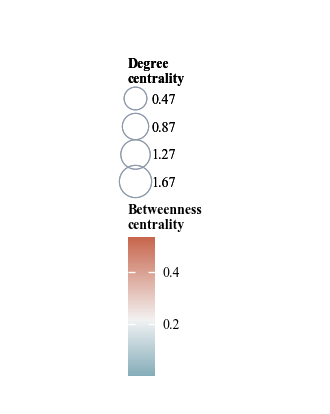

In [38]:
from legendkit import size_legend, colorart
from legendkit import cat_legend, vstack, hstack
# 创建一个新的图形和轴对象
fig, ax = plt.subplots(figsize=(4, 2))
ax.set_axis_off()
# 设置透明背景
fig.patch.set_alpha(0)
quartiles = np.round(np.linspace(global_min_degree, global_max_degree, num=5)[1:], 2)
# 创建大小图例
a=size_legend(sizes=np.arange(global_min_size*18, global_max_size*18, 1), handle="circle", ax=ax,labels=quartiles,colors='#8E9AAB',title='Degree\ncentrality',fill=False)
# 创建颜色映射
original_cmap = sns.diverging_palette(220, 20, as_cmap=True)
start, end = 0.2, 0.95
colors = original_cmap(np.linspace(start, end, 256))
truncated_cmap = LinearSegmentedColormap.from_list("truncated", colors)
# 创建颜色图例
norm = plt.Normalize(vmin=global_min_betweenness, vmax=global_max_betweenness)
mappable = plt.cm.ScalarMappable(norm=norm, cmap=truncated_cmap)
b=colorart(mappable, ax=ax, loc="out right center",title='Betweenness\ncentrality')

vstack([a, b], spacing=10, title="", loc="center", frameon=False, ax=ax)
path = os.path.join(output_folder, f"legendnet.svg")
plt.savefig(path, bbox_inches='tight', pad_inches=0.1)
plt.show()